 # 1.05 — Does rain slow down how fast bikes get taken?

 **H0:** Stations change fill ratio at the same average rate during rainy hours
 and dry hours.
 **H1:** The fill ratio changes at a different rate when it is raining.

 The idea is simple: people are less likely to grab a bike when it is raining.
 If that is true, docks should drain more slowly during rainy hours. I measure
 this with fill_ratio_change_1hr -- the change in dock fill ratio over one hour.
 Negative means bikes left on net (dock got emptier); positive means bikes came
 back on net (dock got fuller). If rain suppresses ridership, rainy hours should
 sit closer to zero or even go slightly positive compared to dry hours.

 Groups: rainy = hours where recorded precipitation > 0 mm; dry = 0 mm.
 Both the weather reading and the fill ratio change come from the same row in
 training_features, so no extra join is needed. Data: 2026 only (May-June),
 horizon_minutes = 60 to keep one row per station-hour.

 Authored as a `# %%` .py file. Export to `.ipynb` via:
   Command Palette -> "Jupyter: Export Current Python File as Jupyter Notebook"

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from scipy import stats
from statsmodels.stats.power import TTestIndPower

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from citibike.config import DB_CONFIG  # noqa: E402

pd.set_option("display.max_columns", 20)

FIGURES_DIR = Path("../reports/figures")

 ## Pull fill ratio changes and the precipitation reading

 Both columns live in training_features, so this is a single table scan.
 I label each row as rainy or dry based on whether any precipitation was
 recorded for that hour.

In [ ]:
conn = psycopg2.connect(**DB_CONFIG)

with conn.cursor() as cur:
    cur.execute("SET max_parallel_workers_per_gather = 0;")

sql = """
    SELECT
        fill_ratio_change_1hr,
        CASE WHEN precipitation > 0 THEN 'rainy' ELSE 'dry' END AS condition
    FROM training_features
    WHERE EXTRACT(YEAR FROM "timestamp") = 2026
      AND horizon_minutes = 60
      AND fill_ratio_change_1hr IS NOT NULL
      AND precipitation IS NOT NULL;
"""
df = pd.read_sql(sql, conn)
conn.close()
print(f"Rows loaded: {len(df):,}")
print(df["condition"].value_counts())

<ipython-input-2-6a68903617c3>:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


Rows loaded: 2,286,092
condition
dry      1931305
rainy     354787
Name: count, dtype: int64


 ## Split into the two groups

 Rainy and dry hours are different observations from different points in time,
 so they are independent samples. I pull them into separate arrays and compare
 their means.

In [ ]:
rainy = df.loc[df["condition"] == "rainy", "fill_ratio_change_1hr"]
dry   = df.loc[df["condition"] == "dry",   "fill_ratio_change_1hr"]

n_rainy = len(rainy)
n_dry   = len(dry)
print(f"Rainy station-hours: n = {n_rainy:,}")
print(f"Dry station-hours:   n = {n_dry:,}")

Rainy station-hours: n = 354,787
Dry station-hours:   n = 1,931,305


 ## Descriptive stats

 A negative mean fill_ratio_change_1hr means bikes are leaving docks on net
 during those hours. I want to see whether the rainy mean sits higher (less
 depletion) than the dry mean, which would confirm that rain keeps people off
 bikes.

In [ ]:
desc = pd.DataFrame({
    "rainy": rainy.describe(percentiles=[0.25, 0.5, 0.75]),
    "dry":   dry.describe(percentiles=[0.25, 0.5, 0.75]),
}).loc[["count", "mean", "std", "25%", "50%", "75%"]]
print(desc.round(5))

              rainy           dry
count  354787.00000  1.931305e+06
mean        0.00148 -4.200000e-04
std         0.07735  8.993000e-02
25%        -0.01754 -3.333000e-02
50%         0.00000  0.000000e+00
75%         0.02041  2.941000e-02


 ## Two-sample Welch t-test

 H0: mean(rainy) - mean(dry) = 0. Welch's t-test handles the fact that the
 two groups are very different sizes and almost certainly have different spreads.

In [ ]:
t_stat, p_value = stats.ttest_ind(rainy, dry, equal_var=False)
mean_rainy = rainy.mean()
mean_dry   = dry.mean()
mean_diff  = mean_rainy - mean_dry

print(f"Mean fill_ratio_change_1hr -- rainy: {mean_rainy:+.5f}")
print(f"Mean fill_ratio_change_1hr -- dry:   {mean_dry:+.5f}")
print(f"Mean difference (rainy - dry):       {mean_diff:+.5f}")
print(f"t = {t_stat:.4f}   p = {p_value:.4e}")

Mean fill_ratio_change_1hr -- rainy: +0.00148
Mean fill_ratio_change_1hr -- dry:   -0.00042
Mean difference (rainy - dry):       +0.00190
t = 13.0869   p = 3.9634e-39


 ## Effect size and 95% CI

 Cohen's d and the confidence interval are what I actually care about here.
 The p-value will be near zero at this sample size regardless of how tiny the
 real difference is, so it does not tell me whether rain matters in practice.

In [ ]:
s_rainy, s_dry = rainy.std(ddof=1), dry.std(ddof=1)

pooled_sd = np.sqrt(
    ((n_rainy - 1) * s_rainy**2 + (n_dry - 1) * s_dry**2)
    / (n_rainy + n_dry - 2)
)
cohens_d = mean_diff / pooled_sd

se_diff = np.sqrt(s_rainy**2 / n_rainy + s_dry**2 / n_dry)
ci_low  = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print(f"Mean difference (rainy - dry): {mean_diff:+.5f}")
print(f"95% CI: [{ci_low:.5f}, {ci_high:.5f}]")
print(f"Cohen's d: {cohens_d:.4f}")

Mean difference (rainy - dry): +0.00190
95% CI: [0.00161, 0.00218]
Cohen's d: 0.0216


 ## Bar chart

 One bar for rainy hours, one for dry. The dashed line at zero is the
 break-even point: bars below it mean docks are losing bikes on net,
 bars above it mean bikes are coming back on net. If rain really slows
 things down, the rainy bar should sit higher (closer to zero or above it)
 than the dry bar.

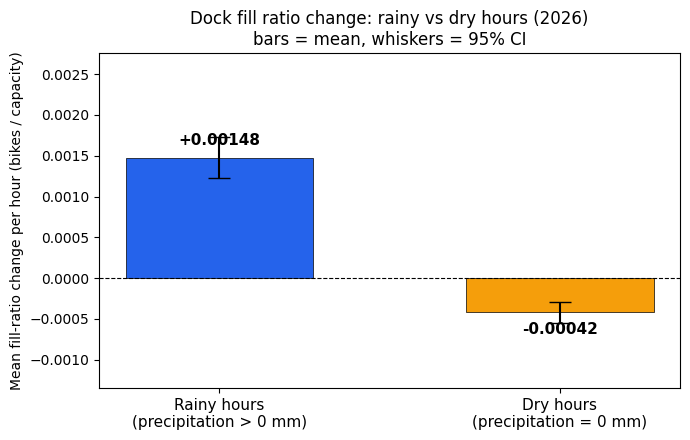

Saved -> reports/figures/1.05_bar_chart.png


In [ ]:
means  = [mean_rainy, mean_dry]
s_vals = [s_rainy, s_dry]
ns     = [n_rainy, n_dry]
errors = [1.96 * s / np.sqrt(n) for s, n in zip(s_vals, ns)]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([0, 1], means, yerr=errors, capsize=8,
       color=["#2563EB", "#F59E0B"], width=0.55,
       edgecolor="black", linewidth=0.5)

y_lo = min(m - e for m, e in zip(means, errors))
y_hi = max(m + e for m, e in zip(means, errors))
span = max(abs(y_hi - y_lo), 0.001)
ax.set_ylim(y_lo - span * 0.35, y_hi + span * 0.45)

for x, m in zip([0, 1], means):
    va     = "bottom" if m >= 0 else "top"
    offset = span * 0.05 if m >= 0 else -span * 0.05
    ax.text(x, m + offset, f"{m:+.5f}", ha="center",
            fontsize=11, fontweight="bold", va=va)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Rainy hours\n(precipitation > 0 mm)", "Dry hours\n(precipitation = 0 mm)"],
                   fontsize=11)
ax.set_ylabel("Mean fill-ratio change per hour (bikes / capacity)", fontsize=10)
ax.set_title(
    "Dock fill ratio change: rainy vs dry hours (2026)\nbars = mean, whiskers = 95% CI",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.05_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/1.05_bar_chart.png")

 ## Retrospective power analysis

 Even though I know the test passed, I want to confirm I had enough data to
 detect the observed effect at 80% power. TTestIndPower returns the minimum
 number of rainy rows needed.

In [ ]:
power_analysis = TTestIndPower()
ratio = n_dry / n_rainy
n_required = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    alpha=0.05,
    power=0.80,
    ratio=ratio,
    alternative="two-sided",
)
print(f"Min rainy rows needed (80% power, a=0.05): {n_required:,.0f}")
print(f"Actual rainy rows:                          {n_rainy:,}")
print(f"Overpowered by:                             {n_rainy / n_required:,.1f}x")

Min rainy rows needed (80% power, a=0.05): 19,997
Actual rainy rows:                          354,787
Overpowered by:                             17.7x


 ## Conclusion

 I reject H0, but the effect is negligible in practice. Rain barely changes anything. On rainy hours, docks inch slightly fuller on net
 (+0.00148 fill ratio per hour). On dry hours, they inch slightly emptier (-0.00042).
 The difference is real and confirmed by the test, but it is so small it would never
 show up in practice. The gap works out to less than a tenth of a bike per dock per
 hour -- on a 20-dock station, the difference between a rainy and a dry hour is
 roughly 0.04 of a bike. Nobody would notice that.

 The direction makes sense: fewer people want to ride in the rain, so bikes sit at
 docks a bit longer. But the signal is faint. The pattern from 1.03 -- morning rush
 draining stations, evening returning them -- is about 11x larger than the rain effect.
 Time of day and commuter flow are what move the needle. Weather is a minor footnote.

 The test only picks this up at all because I have 2.3 million rows. With a standard
 dataset, this difference would be invisible. I needed 20,000 rainy station-hours to
 detect it at 80% power; I had 355,000 -- 17.7x what was required.

 **Limitations:** May-June 2026 only, so autumn and winter rain are not captured.
 Those seasons may show a stronger effect. Light drizzle and heavy downpours are
 treated the same here (both are just precipitation > 0). A breakdown by intensity
 would likely show that heavy rain suppresses ridership much more.